<a href="https://colab.research.google.com/github/s8narnor/Multimodal-AI/blob/main/multimodal_ai_workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multimodal AI Workshop
### From Pixels to Language: Vision + Language AI Systems

In this notebook we explore how modern AI models combine **computer vision and natural language processing**.

Sections:
1. Environment Setup
2. Image Captioning
3. Visual Question Answering
4. Image–Text Similarity using CLIP
5. Interactive Demo

In [1]:
# !pip install transformers torch torchvision pillow

## Import Libraries

In [2]:
from transformers import pipeline
from PIL import Image
import requests
import torch

In [3]:
import warnings
warnings.filterwarnings("ignore")

from transformers.utils import logging
logging.set_verbosity_error()

## Image Captioning
Generate a natural language description for an image.

preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

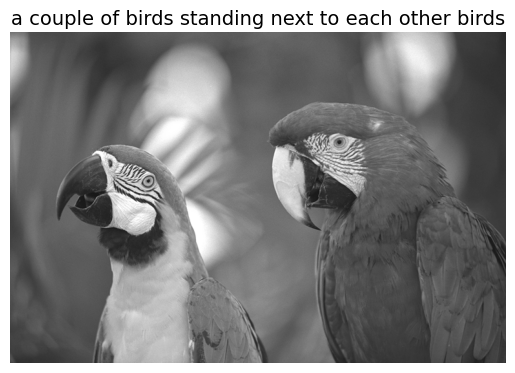

In [4]:
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import requests
import torch
import matplotlib.pyplot as plt

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

image_url = "https://huggingface.co/datasets/Narsil/image_dummy/raw/main/parrots.png"
image = Image.open(requests.get(image_url, stream=True).raw).convert("RGB")

inputs = processor(images=image, return_tensors="pt")

out = model.generate(
    **inputs,
    max_new_tokens=20,
    num_beams=5
)

caption = processor.decode(out[0], skip_special_tokens=True)

# Display image
plt.imshow(image)
plt.axis("off")

# Show caption below image
plt.title(caption, fontsize=14)

plt.show()

## Visual Question Answering
Ask questions about an image.

In [5]:
vqa = pipeline("visual-question-answering")

question = "How many birds are in the image?"
result = vqa(image=image, question=question)

print(result)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/470M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/470M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/320 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/251 [00:00<?, ?B/s]

[{'score': 0.9560691118240356, 'answer': '2'}, {'score': 0.07942558825016022, 'answer': '3'}, {'score': 0.0027186248917132616, 'answer': 'yes'}, {'score': 0.001823930419050157, 'answer': '4'}, {'score': 0.0017589738126844168, 'answer': '1'}]


## CLIP: Image–Text Similarity
CLIP maps images and text into the same embedding space.

In [6]:
from transformers import CLIPProcessor, CLIPModel

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

texts = ["a photo of a bird", "a photo of a dog", "a photo of a car"]

inputs = processor(text=texts, images=image, return_tensors="pt", padding=True)
outputs = model(**inputs)

logits = outputs.logits_per_image
probs = logits.softmax(dim=1)

print(probs)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

tensor([[0.9978, 0.0011, 0.0011]], grad_fn=<SoftmaxBackward0>)


## Interactive Demo
Upload any image and test captioning or ask questions.

Saving example.jpeg to example.jpeg


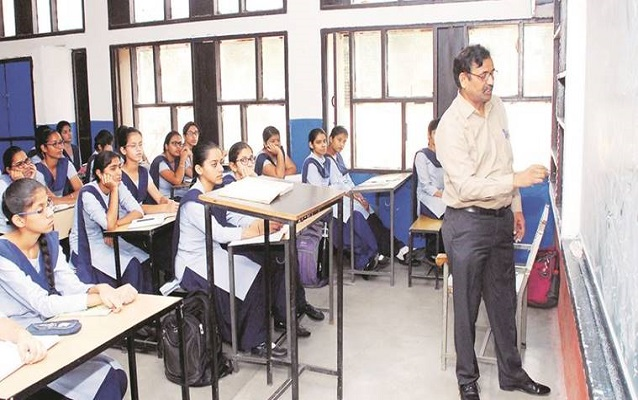

In [7]:
# For Google Colab users
from google.colab import files
uploaded = files.upload()

image = Image.open(list(uploaded.keys())[0])
image

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

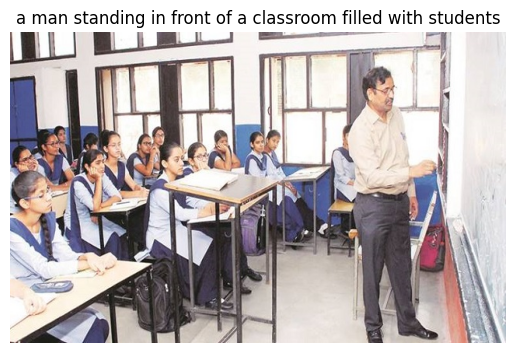

In [8]:
# from transformers import BlipProcessor, BlipForConditionalGeneration

# # Load the BLIP model specifically for this interactive section
# blip_processor_interactive = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
# blip_model_interactive = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

image = image.convert("RGB")

inputs = blip_processor_interactive(images=image, return_tensors="pt")

out = blip_model_interactive.generate(
    **inputs,
    max_new_tokens=20,
    num_beams=5
)

caption = blip_processor_interactive.decode(out[0], skip_special_tokens=True)

plt.imshow(image)
plt.axis("off")
plt.title(caption)
plt.show()

In [9]:
texts = ["a photo of a man teaching", "a photo of a woman teaching", "a photo of a person teaching"]

inputs = processor(text=texts, images=image, return_tensors="pt", padding=True)
outputs = model(**inputs)

logits = outputs.logits_per_image
probs = logits.softmax(dim=1)

print(probs)

tensor([[0.5041, 0.0756, 0.4203]], grad_fn=<SoftmaxBackward0>)
